# Cash-Flow-Volatility -- do steady cash generators quietly win?
### Huang (2009): the cash-flow-uncertainty anomaly, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Huang--direction%3F: Busted](https://img.shields.io/badge/Huang--direction%3F-Busted-8b949e?style=flat-square)

In 2009, Alan Huang published a quiet but pointed finding: firms with more **volatile operating cash flows** earn **lower** future returns. Stable, predictable cash generators are rewarded; cash-flow lottery tickets are not. It is a quality-like anomaly -- a cousin of low-volatility and quality-minus-junk.

We test that claim on a 40-name large-cap survivor basket using yfinance daily prices and quarterly cash-flow statements -- naming the survivorship bias and the thin (~5-quarter) fundamental history up front.

> **This is the plain-language layer.** Want the multi-seed control, the placebo null, and the split-fraction robustness? See the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_flow_volatility import data, strategy as st

# Frozen headline numbers (mirror docs/results.md, as-of 2026-06-26) -- used when no cache.
R = dict(
    n_months=95, year_start=2018, year_end=2025, n_tickers=40, n_per_leg=13,
    ls_mean=-3.43, ls_vol=9.81, ls_sharpe=-0.350, ls_t=-1.027,
    ls_hit=43.2, ls_dd=-34.7,
    low_leg=15.24, high_leg=18.67, spy_mean=14.25,
    placebo_p=0.357, real_mean_mo=-0.286,
    net_mean=-4.61, net_t=-1.381, cost_drag=1.18,
    fp_prices="6385498e2186", fp_cfvol="9f5b76cfb791",
    splits={"quintile": (-4.56, -0.85), "tercile": (-3.43, -1.03), "half": (-0.87, -0.26)},
    annual={2018: 1.2, 2019: -7.2, 2020: -16.5, 2021: 16.6,
            2022: -8.8, 2023: 1.2, 2024: -11.7, 2025: -1.6},
)

def _have_cache():
    import os
    study = os.path.abspath("..")
    c = os.path.join(study, "_cache")
    return all(os.path.exists(os.path.join(c, f)) for f in
               ("cfvol_prices.parquet", "cfvol_spy.parquet", "cfvol_signal.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy, cfvol = data.fetch_panel()
    ls = st.build_real(prices, cfvol, exec_lag=1)
    s_ls  = st.summary(ls["ls_ret"])
    s_low = st.summary(ls["low_ret"])
    s_high= st.summary(ls["high_ret"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True
N months: 95 | LS mean: -3.43%/yr | HAC t: -1.027


## The answer first

| Question | Answer |
|---|---|
| Do low-CF-vol firms out-earn high-CF-vol firms? | **No -- the opposite, weakly.** Long-low / short-high earns **-3.43%/yr**, HAC *t* = **-1.03** (wrong sign). |
| Is it distinguishable from random labels? | **No.** Label-shuffle placebo *p* = **0.36**. |
| Is it tradable? | **No.** Negative gross and net (**-4.61%/yr** net), Sharpe **-0.35**. |
| Survivorship / data problem? | **Yes, and we name both.** Basket = survivors; CF-vol rests on only ~5 quarters of yfinance fundamentals. |

> The Huang (2009) cash-flow-uncertainty premium is documented on long Compustat histories. On 40 large-cap survivors with a thin yfinance signal window, it is absent -- and the high-CF-vol leg actually led the tape.

## 1 -- The claim

> *"Firms with more volatile operating cash flows earn lower average returns. Cash-flow uncertainty is a priced characteristic: stable cash generators are rewarded, volatile ones are penalised."*

-- Huang (2009), *Journal of Empirical Finance*

The intuition: volatile cash flows raise the cost of external finance, force firms to skip good investments, and make earnings hard to forecast. Uncertainty-averse investors discount such firms. So a portfolio **long low-CF-vol** and **short high-CF-vol** should earn a positive quality-like premium.

## 2 -- So what?

If true, cash-flow stability is a free lunch hiding inside the income statement: a signal you can compute from public filings, uncorrelated with size or value, that tilts you toward boring, dependable compounders. It is one of the 'safety' inputs in AQR's *Quality Minus Junk* (see [Study 242](../../242-quality-minus-junk/)).

The questions for us:
1. **Does it survive on a realistic large-cap basket?**
2. **Can yfinance even serve enough cash-flow history to measure it?**
3. **What is the survivorship bias?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **A synthetic positive control.** Before trusting the engine on real data, we plant a known CF-vol premium in a fake market and check the long-short recovers it (averaged over 20 seeds), and returns noise when the premium is zero.
2. **A label-shuffle placebo.** Permute the CF-vol labels across names, re-sort, recompute. If the real long-short sits inside that null, there is no signal.
3. **Name the biases.** The basket is *current* survivors -- failed high-CF-vol firms are gone. And yfinance serves only ~5 quarters, so the signal is thin. Both inflate the result upward, and it is *still* negative.

## 4 -- The teardown

**First, does the engine work when the effect is planted?**

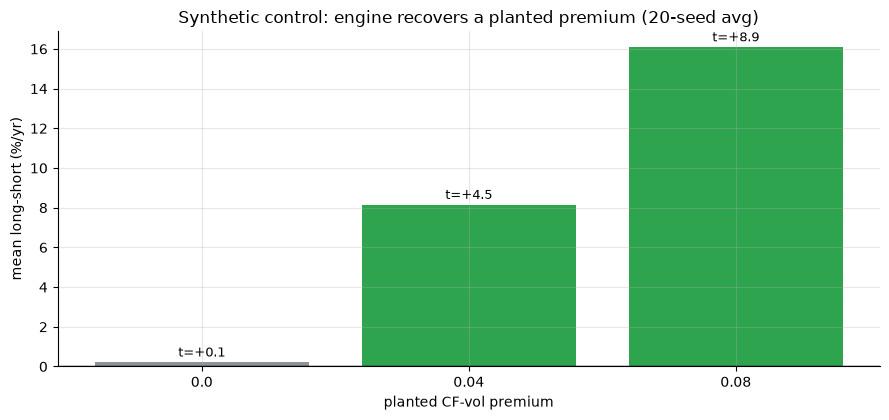

 premium  mean_ls_%  avg_t  frac_sig  n_seeds
    0.00      0.202  0.109      0.15       20
    0.04      8.142  4.507      0.95       20
    0.08     16.083  8.904      1.00       20


In [2]:
ctrl = st.synthetic_control(premiums=(0.0, 0.04, 0.08), n_seeds=20)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else GREY for m in ctrl['mean_ls_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['mean_ls_%'], color=col)
for i, (m, t) in enumerate(zip(ctrl['mean_ls_%'], ctrl['avg_t'])):
    ax.text(i, m + 0.3, f't={t:+.1f}', ha='center', fontsize=9)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted CF-vol premium'); ax.set_ylabel('mean long-short (%/yr)')
ax.set_title('Synthetic control: engine recovers a planted premium (20-seed avg)')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: ~zero at the null (avg *t* = +0.11), strongly positive and significant when a premium is planted. So the verdict on the real tape reflects **the market**, not a broken method. *(This control is a power check only -- never evidence for the real-tape stamp.)*

**Now the honest test on the real yfinance basket.**

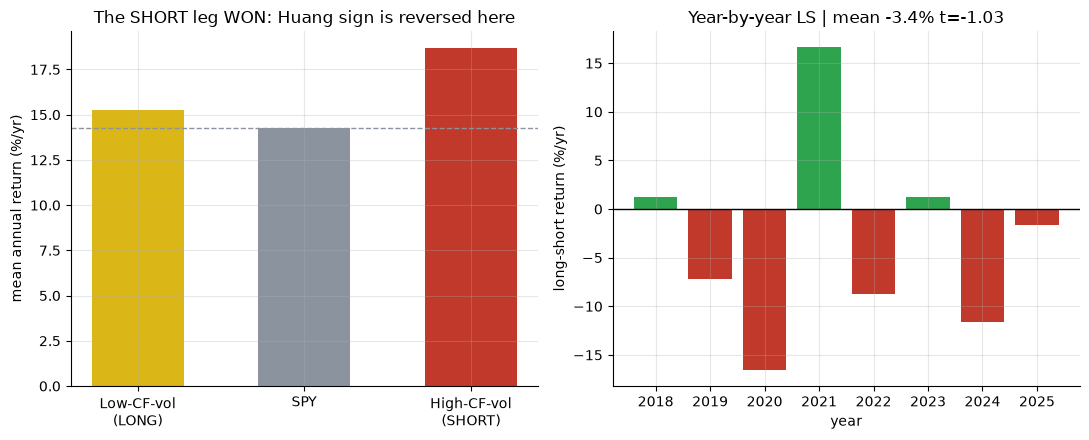

Long-short: -3.43%/yr | HAC t = -1.027


In [3]:
if HAVE_REAL:
    low_m, high_m = s_low['mean']*100, s_high['mean']*100
    ls_m, ls_t = s_ls['mean']*100, s_ls['tstat']
    yb = ls.copy(); yb['year'] = [p.year for p in yb.index]
    annual = yb.groupby('year')['ls_ret'].apply(lambda x: float((1+x).prod()-1))*100
else:
    low_m, high_m = R['low_leg'], R['high_leg']
    ls_m, ls_t = R['ls_mean'], R['ls_t']
    annual = pd.Series(R['annual'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(['Low-CF-vol\n(LONG)', 'SPY', 'High-CF-vol\n(SHORT)'],
            [low_m, R['spy_mean'], high_m], color=[AMBER, GREY, RED], width=0.55)
axes[0].axhline(R['spy_mean'], ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('The SHORT leg WON: Huang sign is reversed here')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index, annual.values, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('long-short return (%/yr)')
axes[1].set_title(f'Year-by-year LS | mean {ls_m:+.1f}% t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Long-short: {ls_m:+.2f}%/yr | HAC t = {ls_t:+.3f}')

The long-short earns **-3.4%/yr** at HAC *t* = **-1.03** -- below the bar *and* the wrong sign. The high-CF-vol leg (**+18.7%/yr**) beat the low-CF-vol leg (**+15.2%/yr**): on this 2018-2025 large-cap tape, the volatile cash generators led.

## 5 -- The verdict

- **Signal -- NONE.** HAC *t* = -1.03, placebo *p* = 0.36, sign reversed. Robust across quintile/tercile/half splits. Literature support alone never lifts the verdict on this desk -- the real tape is silent.
- **Tradability -- MIRAGE.** Negative gross (-3.43%/yr) and net (-4.61%/yr), Sharpe -0.35, max DD -34.7%. Nothing for costs to erode.
- **Huang direction -- BUSTED (on this tape).** The high-CF-vol leg won. On survivors with a thin signal window, the anomaly is absent and the sign flips.

## 6 -- Could you actually trade it?

There is no gross edge to trade, so the costs question is moot -- but for the record:

1. **Short borrow.** The high-CF-vol short leg (often growth/cyclicals) can be expensive to borrow.
2. **Thin signal.** With only ~5 quarters of yfinance data, the CF-vol estimate is noisy and slow to update -- not a tradable, frequently-refreshed factor.
3. **Survivorship.** The names that would have made the short leg pay -- firms whose cash flows blew up and that delisted -- are not in the basket.

A Compustat-grade replication over a long history might recover Huang's result. On this evidence, the verdict is **Mirage**.

## 7 -- Going further

- **Long history.** Huang (2009) used Compustat back to the 1980s. A real replication needs quarterly cash flows far beyond yfinance's ~5-quarter window.
- **Broader universe.** The premium (like most anomalies) is strongest in small/microcaps, which are absent from this large-cap basket.
- **Quality umbrella.** [Study 242 -- Quality-Minus-Junk](../../242-quality-minus-junk/) bundles CF-vol 'safety' with profitability and growth.
- **Cousins.** [Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/) (return vol) and [Study 231 -- Sloan-Accruals](../../231-sloan-accruals/) (cash-flow vs accrual quality).

*Think CF-vol survives net of costs on a long, unbiased history? Fork this, wire Compustat-grade quarterly cash flows, expand to Russell 3000, and show t > 2 net. That is the bar.*